## Classification

In [8]:
import pandas as pd
import numpy as np

# Load the data header and the data files

In [10]:
# load data header (columns)
with open("census-bureau.columns") as f:
    columns = [c.strip() for c in f.readlines()]

In [11]:
# load data
data = pd.read_csv("census-bureau.data", header=None, names=columns)

# Initial data inspections

In [4]:
data.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [5]:
data.shape

(199523, 42)

In [6]:
columns

['age',
 'class of worker',
 'detailed industry recode',
 'detailed occupation recode',
 'education',
 'wage per hour',
 'enroll in edu inst last wk',
 'marital stat',
 'major industry code',
 'major occupation code',
 'race',
 'hispanic origin',
 'sex',
 'member of a labor union',
 'reason for unemployment',
 'full or part time employment stat',
 'capital gains',
 'capital losses',
 'dividends from stocks',
 'tax filer stat',
 'region of previous residence',
 'state of previous residence',
 'detailed household and family stat',
 'detailed household summary in household',
 'weight',
 'migration code-change in msa',
 'migration code-change in reg',
 'migration code-move within reg',
 'live in this house 1 year ago',
 'migration prev res in sunbelt',
 'num persons worked for employer',
 'family members under 18',
 'country of birth father',
 'country of birth mother',
 'country of birth self',
 'citizenship',
 'own business or self employed',
 "fill inc questionnaire for veteran's admin"

In [7]:
data.isna().sum()

age                                             0
class of worker                                 0
detailed industry recode                        0
detailed occupation recode                      0
education                                       0
wage per hour                                   0
enroll in edu inst last wk                      0
marital stat                                    0
major industry code                             0
major occupation code                           0
race                                            0
hispanic origin                               874
sex                                             0
member of a labor union                         0
reason for unemployment                         0
full or part time employment stat               0
capital gains                                   0
capital losses                                  0
dividends from stocks                           0
tax filer stat                                  0


In [8]:
sum(data.isna().sum())

874

Missing data observed in the column 'hispanic origin' which also contains ambiguous answers like 'Do not know' 

In [9]:
print(data["hispanic origin"].value_counts(dropna=False).head(20))

hispanic origin
All other                    171907
Mexican-American               8079
Mexican (Mexicano)             7234
Central or South American      3895
Puerto Rican                   3313
Other Spanish                  2485
Cuban                          1126
NaN                             874
Do not know                     306
Chicano                         304
Name: count, dtype: int64


In [10]:
for col in data.columns:
    if data[col].dtype == "object":
        if data[col].str.contains("Do not know", na=False).any():
            print(col)

hispanic origin


Look for other missing data encoded as 'Not in universe'

In [11]:
data.apply(lambda x: x.astype(str).str.contains("Not in universe", case=False).sum())

age                                                0
class of worker                               100245
detailed industry recode                           0
detailed occupation recode                         0
education                                          0
wage per hour                                      0
enroll in edu inst last wk                    186943
marital stat                                       0
major industry code                           100684
major occupation code                         100684
race                                               0
hispanic origin                                    0
sex                                                0
member of a labor union                       180459
reason for unemployment                       193453
full or part time employment stat                  0
capital gains                                      0
capital losses                                     0
dividends from stocks                         

Standardize the columns before formal preprocessing

In [12]:
object_cols = data.select_dtypes(include=["object"]).columns
for col in object_cols:
    data[col] = data[col].str.strip()   # remove extra whitespaces in string columns


In [13]:
data["label"].value_counts(dropna=False)

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [14]:
# one-hot encode the labels 

label_map = {
    "- 50000.": 0,
    "50000+.": 1
}

data["label"] = data["label"].replace(label_map)

C:\Users\Zihao\AppData\Local\Temp\ipykernel_30380\4030622916.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["label"] = data["label"].replace(label_map)


In [15]:
data["label"].value_counts(dropna=False)

label
0    187141
1     12382
Name: count, dtype: int64

In [16]:
# convert all the ambiguous responses to nan

missing_tokens_map = {
    "Do not know": np.nan,
    "Unknown": np.nan,
    "NA": np.nan,
    "": np.nan,
    "?": np.nan  # include more possibilities for missing data
}

data = data.replace(missing_tokens_map)

In [17]:
# separate the weights from the data for now because they complicate the stratified cross validations in model selections and hyperparameter tuning
# we will use weights when training the final model

weights = data["weight"].copy()
data = data.drop(columns=["weight"])

Separate the features into numeric and categorical groups. Note that although some features are recorded with numeric values, they should in fact be treated as categorical (e.g. "detailed industry recode" and "detailed occupation recode").

In [18]:
numeric_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "num persons worked for employer",
    "weeks worked in year",
    "year"
]

# these columns should contain truly numeric information

In [19]:
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce") # turn all the inputs from the numeric columns to numeric values

In [20]:
# all the remaining columns will be treated as categorical

categorical_cols = [
    col for col in data.columns
    if col not in numeric_cols + ["label"]
]

for col in categorical_cols:
    data[col] = data[col].astype("object")  # turn their data type to object to distinguish them from numeric information

# Train-test split and preprocessing pipelines

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [22]:
X = data.drop(columns=["label"])
y = data["label"]

Data imbalance observed. This suggests that we will need to handle the imbalance with care in later modeling procedure, and use appropriate metrics to evaluate the models.

In [23]:
print(y.value_counts(dropna=False))
print(y.value_counts(normalize=True))


label
0    187141
1     12382
Name: count, dtype: int64
label
0    0.937942
1    0.062058
Name: proportion, dtype: float64


In [24]:
# stratified train-test split according to the label

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights,
    test_size=0.2,
    random_state=43210,
    stratify=y
)

In [25]:
print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (159618, 40)
Test shape: (39905, 40)


In [26]:
print(y_train.value_counts(dropna=False))
print(y_train.value_counts(normalize=True))


label
0    149712
1      9906
Name: count, dtype: int64
label
0    0.937939
1    0.062061
Name: proportion, dtype: float64


In [53]:
weighted_counts = (
    pd.DataFrame({"label": y_train, "weight": w_train})
    .groupby("label")["weight"]
    .sum()
)

print(weighted_counts)

label
0    2.598831e+08
1    1.777443e+07
Name: weight, dtype: float64


In [48]:
print(y_test.value_counts(dropna=False))
print(y_test.value_counts(normalize=True))

label
0    37429
1     2476
Name: count, dtype: int64
label
0    0.937953
1    0.062047
Name: proportion, dtype: float64


In [54]:
weighted_counts = (
    pd.DataFrame({"label": y_test, "weight": w_test})
    .groupby("label")["weight"]
    .sum()
)

print(weighted_counts)

label
0    65121524.11
1     4466817.71
Name: weight, dtype: float64


In [55]:
weighted_counts = (
    pd.DataFrame({"label": y, "weight": weights})
    .groupby("label")["weight"]
    .sum()
)

print(weighted_counts)

label
0    3.250046e+08
1    2.224125e+07
Name: weight, dtype: float64


Preprocessing pipelines

In [27]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # fill na with medians in numeric columns
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")), # fill na with "Missing" in categorical columns (this covers NaN, "Do not know", or other similar responses)
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Cross validation and model selection

In [28]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43210)

In [30]:
# consider logistic regression, random forest, and xgboost

models = {
    "dummy": Pipeline([
        ("prep", preprocess),
        ("model", DummyClassifier())
    ]),

    "logreg": Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced"  # to fight data imbalance
        ))
    ]),

    "rf": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "xgb": Pipeline([
        ("prep", preprocess),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=15,     # (# negative / # positive) in the training set is roughly 15
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

In [31]:
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",  # consider PR AUC because of the class imbalance
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

# note that accuracy will not help due to the class imbalance

results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results[name] = scores

In [56]:
summary = {}

for name, res in results.items():
    summary[name] = {
        metric: res[f"test_{metric}"].mean()
        for metric in scoring.keys()
    }

summary_df = pd.DataFrame(summary).T
print(summary_df)

         roc_auc    pr_auc        f1  precision    recall
dummy   0.500000  0.062061  0.000000   0.000000  0.000000
logreg  0.944857  0.604850  0.435805   0.288131  0.894004
rf      0.936445  0.561426  0.457799   0.318089  0.816374
xgb     0.952758  0.671486  0.478506   0.328782  0.878660


Based on the summary, we choose XGboost for its better performance especially in PR AUC and ROC AUC. It's result is also decent under other metrics. We note that all three models perform a lot better than a dummy baseline (random guesser).

In [33]:
# XGBoost is a tree algorithm that does not need standard scaling, so we redefine the preprocessing pipeline for XGBoost

preprocess_xgb = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

# Model tuning and training

We will now tune XGBoost with optuna

In [34]:
import optuna
from sklearn.base import clone
from sklearn.metrics import average_precision_score # PR AUC

In [ ]:
# objective function for tuning
# we tune for the PR AUC metric, taking the class imbalance into account

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-2, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 10.0, 20.0),
    }

    model = Pipeline([
        ("prep", preprocess_xgb),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=43210,
            n_jobs=-1,
            **params
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43210)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        fitted_model = clone(model)
        fitted_model.fit(X_tr, y_tr) # weights are not considered for a cleaner cross validation

        y_prob = fitted_model.predict_proba(X_val)[:, 1]
        score = average_precision_score(y_val, y_prob)   # PR AUC
        scores.append(score)

    return np.mean(scores)

In [36]:
# run the tuning with optuna

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best trial:")
print(study.best_trial.value)
print(study.best_trial.params)

[I 2026-03-09 14:41:22,377] A new study created in memory with name: no-name-ffbd52f1-3866-4710-a818-76a7c4a05dee
[I 2026-03-09 14:41:41,182] Trial 0 finished with value: 0.6665059648598783 and parameters: {'n_estimators': 425, 'max_depth': 10, 'learning_rate': 0.013688454841339804, 'subsample': 0.7134347869354518, 'colsample_bytree': 0.7795728156918482, 'min_child_weight': 10, 'gamma': 0.6840458341039557, 'reg_alpha': 1.287649965625464, 'reg_lambda': 0.020299497887732283, 'scale_pos_weight': 17.51827856259086}. Best is trial 0 with value: 0.6665059648598783.
[I 2026-03-09 14:42:01,169] Trial 1 finished with value: 0.6749400718982252 and parameters: {'n_estimators': 790, 'max_depth': 7, 'learning_rate': 0.059431057545896816, 'subsample': 0.6338291665178707, 'colsample_bytree': 0.6563327973897745, 'min_child_weight': 9, 'gamma': 1.7275770783969908, 'reg_alpha': 0.005190365788162571, 'reg_lambda': 0.042911554734817337, 'scale_pos_weight': 11.805245687591253}. Best is trial 1 with value: 

Best trial:
0.679522359181811
{'n_estimators': 465, 'max_depth': 8, 'learning_rate': 0.04589747133780383, 'subsample': 0.9974584770880915, 'colsample_bytree': 0.6231753971004456, 'min_child_weight': 8, 'gamma': 0.03337467257878535, 'reg_alpha': 0.020648844579273684, 'reg_lambda': 4.77431447351227, 'scale_pos_weight': 12.483327173931553}


In [ ]:
best_params = study.best_trial.params

# final model with tuned XGBoost
final_model = Pipeline([
    ("prep", preprocess_xgb),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=43210,
        n_jobs=-1,
        **best_params
    ))
])

final_model.fit(X_train, y_train, model__sample_weight=w_train) # train the final model on the entire train set, together with weights

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['age', 'wage per hour',
                                                   'capital gains',
                                                   'capital losses',
                                                   'dividends from stocks',
                                                   'num persons worked for '
                                                   'employer',
                                                   'weeks worked in year',
                                                   'year']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(hand...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.04589747133780383, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=8,
                               max_leaves=None, min_child_weight=8, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=465, n_jobs=-1,
                               num_parallel_tree=None, random_state=43210, ...))])

# Model testing

In [40]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# make predictions on the testing set

y_prob = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

In [42]:
# compute ROC AUC and PR AUC with weights on the testing set

roc = roc_auc_score(
    y_test,
    y_prob,
    sample_weight=w_test
)

pr = average_precision_score(
    y_test,
    y_prob,
    sample_weight=w_test
)

print("Weighted ROC-AUC:", roc)
print("Weighted PR-AUC:", pr)

Weighted ROC-AUC: 0.9533091336812645
Weighted PR-AUC: 0.6871051782474106


In [45]:
uw_roc = roc_auc_score(y_test, y_prob)
uw_pr = average_precision_score(y_test, y_prob)

print("Unweighted ROC-AUC:", uw_roc)
print("Unweighted PR-AUC:", uw_pr)


Unweighted ROC-AUC: 0.9538320771549329
Unweighted PR-AUC: 0.6876020922606725


In [43]:
# other metrics with weights on the testing set

precision = precision_score(
    y_test,
    y_pred,
    sample_weight=w_test
)

recall = recall_score(
    y_test,
    y_pred,
    sample_weight=w_test
)

f1 = f1_score(
    y_test,
    y_pred,
    sample_weight=w_test
)

print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1:", f1)

Weighted Precision: 0.38161296725603583
Weighted Recall: 0.8554660158719575
Weighted F1: 0.5277867123377039


In [46]:
uw_precision = precision_score(y_test, y_pred)
uw_recall = recall_score(y_test, y_pred)
uw_f1 = f1_score(y_test, y_pred)

print("Unweighted Precision:", uw_precision)
print("Unweighted Recall:", uw_recall)
print("Unweighted F1:", uw_f1)

Unweighted Precision: 0.375354609929078
Unweighted Recall: 0.8550080775444265
Unweighted F1: 0.5216855593888615


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    sample_weight=w_test
)

print(cm) # weighted confusion matrix, representing the model performance on the actual population

[[58929420.11999992  6192103.99000001]
 [  645606.96        3821210.75      ]]


In [ ]:
print(confusion_matrix(y_test, y_pred)) # Unweighted confusion matrix, representing the model performance on the data points

[[33906  3523]
 [  359  2117]]


Feature importance

In [49]:
xgb_model = final_model.named_steps["model"]
importances = xgb_model.feature_importances_

preprocess = final_model.named_steps["prep"]
feature_names = preprocess.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
69,cat__detailed occupation recode_0,0.198608
17,cat__detailed industry recode_0,0.084241
219,cat__tax filer stat_Nonfiler,0.065212
6,num__weeks worked in year,0.017336
174,cat__major occupation code_Other service,0.014057
364,cat__family members under 18_Not in universe,0.012034
318,cat__detailed household summary in household_C...,0.011066
177,cat__major occupation code_Professional specialty,0.009461
169,cat__major occupation code_Executive admin and...,0.008888
197,cat__sex_Male,0.008286


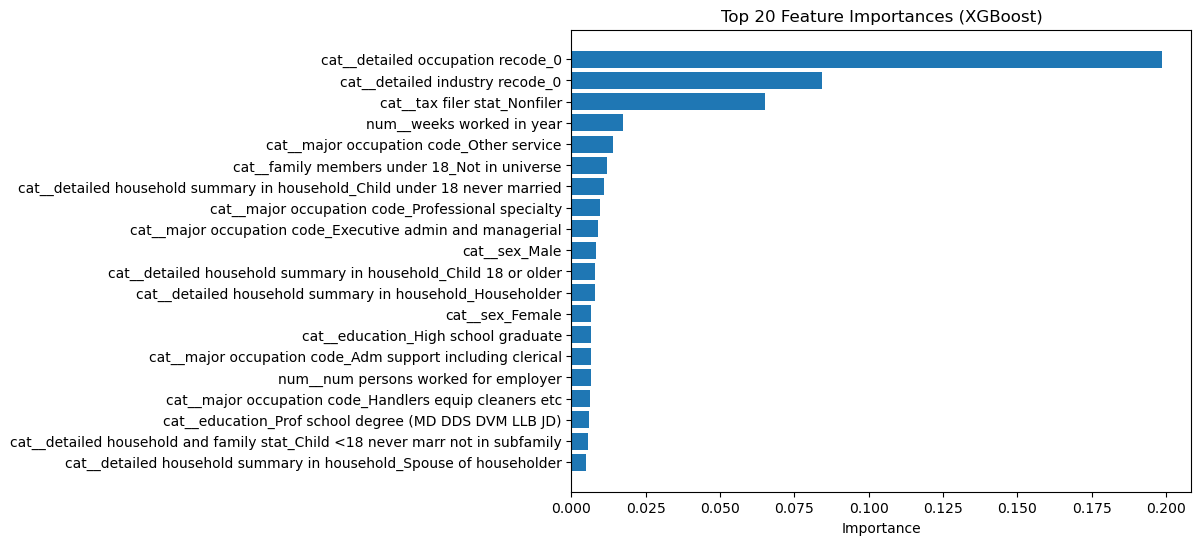

In [50]:
import matplotlib.pyplot as plt

top_features = importance_df.head(20)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()